# Deep Learning from Scratch

En este notebook, construiremos un modelo de **Deep Learning desde cero** para predecir la presencia de neumonía en imágenes de rayos X.

El objetivo es ver si conseguimos superar el rendimiento del baseline de Machine Learning clásico (AUC-ROC = 0.927, recall PNEUMONIA = 0.99) y mejorar el balance entre recall y precisión, aprovechando la capacidad de las redes neuronales para aprender características directamente de las imágenes.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import models, layers, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, RocCurveDisplay)
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

CLASSES     = ["NORMAL", "PNEUMONIA"]
INPUT_SHAPE = (224, 224, 1)  # escala de grises

TensorFlow: 2.19.0
GPU disponible: []


In [ ]:
# ─── CARGAR DATOS ──────────────────────────────────────────────────────────
from google.colab import drive
import zipfile

drive.mount('/content/drive')

ZIP_PATH = "/content/drive/MyDrive/chest_xray_npy.zip"
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall("/content/chest_xray_npy")

SAVE_DIR = "/content/chest_xray_npy"

X_train = np.load(f"{SAVE_DIR}/X_train.npy")
y_train = np.load(f"{SAVE_DIR}/y_train.npy")
X_val   = np.load(f"{SAVE_DIR}/X_val.npy")
y_val   = np.load(f"{SAVE_DIR}/y_val.npy")
X_test  = np.load(f"{SAVE_DIR}/X_test.npy")
y_test  = np.load(f"{SAVE_DIR}/y_test.npy")

# Añadir canal explícito para Keras: (N, 224, 224) → (N, 224, 224, 1)
X_train = X_train[..., np.newaxis]
X_val   = X_val[...,   np.newaxis]
X_test  = X_test[...,  np.newaxis]

print(f"Train : {X_train.shape} | Val : {X_val.shape} | Test : {X_test.shape}")

Mounted at /content/drive
Train : (5216, 224, 224, 1) | Val : (16, 224, 224, 1) | Test : (624, 224, 224, 1)


### Compensar desbalanceo detectado en el EDA

El dataset presenta un desbalanceo entre las clases NORMAL y PNEUMONIA.

Para abordar este problema, calculamos **pesos de clase balanceados** que serán utilizados durante el entrenamiento.
Esto asegura que el modelo no favorezca la clase mayoritaria y preste suficiente atención a la clase minoritaria (PNEUMONIA).

In [ ]:
# CLASS WEIGHTS
from sklearn.utils.class_weight import compute_class_weight

cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weight_dict = dict(enumerate(cw))
print(f"Class weights: {class_weight_dict}")

Class weights: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


### Data Augmentation

Aplicamos **Data Augmentation** para aumentar la diversidad del conjunto de entrenamiento y reducir el riesgo de overfitting.
Utilizamos transformaciones conservadoras, como rotaciones leves, zoom y pequeños desplazamientos, que son apropiadas para imágenes médicas.",

Es importante destacar que el conjunto de validación y prueba no se augmentan, ya que deben representar datos reales y no manipulados.


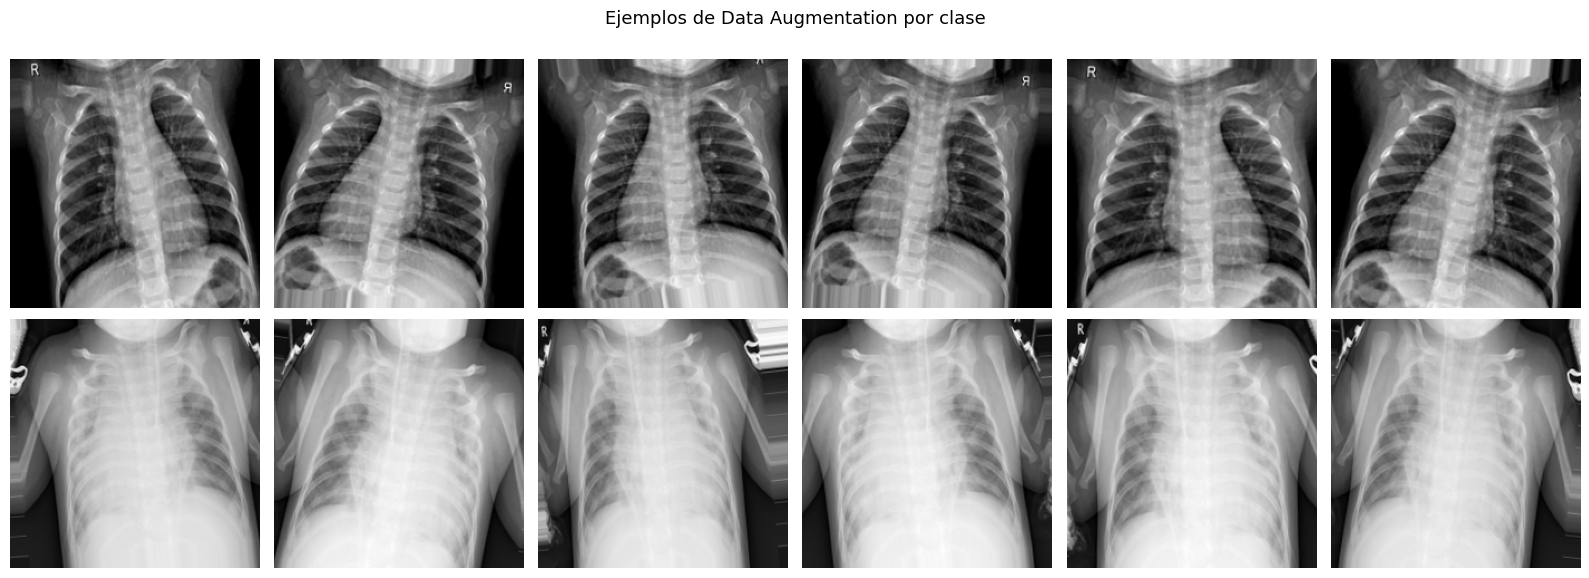

In [ ]:
train_datagen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator()  # sin augmentation

train_gen = train_datagen.flow(X_train, y_train, batch_size=32)
val_gen   = val_datagen.flow(X_val,   y_val,   batch_size=32, shuffle=False)

# Visualizar ejemplos de augmentation
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
sample     = X_train[:1]
aug_iter   = train_datagen.flow(sample, batch_size=1)

for row, cls_idx in enumerate([0, 1]):
    idx  = np.where(y_train == cls_idx)[0][0]
    samp = X_train[idx:idx+1]
    gen  = train_datagen.flow(samp, batch_size=1)
    for col in range(6):
        aug_img = next(gen)[0]
        axes[row][col].imshow(aug_img[:, :, 0], cmap='gray')
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_ylabel(CLASSES[cls_idx],
                                      fontsize=11, fontweight='bold')

plt.suptitle("Ejemplos de Data Augmentation por clase", fontsize=13)
plt.tight_layout()
plt.show()

## CNN from Scratch

Diseñamos una red neuronal convolucional (CNN) desde cero, inspirada en arquitecturas vistas en clase.

La arquitectura incluye bloques de capas **Conv2D** seguidos de **MaxPooling** y **BatchNormalization**, con un clasificador denso al final.

Se utiliza **Dropout** para regularización y una capa de salida con activación sigmoide para la clasificación binaria.

In [ ]:
def build_cnn(input_shape=(224, 224, 1)):
    model = models.Sequential([
        # Bloque 1
        layers.Conv2D(32, (3, 3), activation='relu',
                      padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Bloque 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Bloque 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Bloque 4
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Clasificador
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')  # binario
    ])
    return model

model_scratch = build_cnn(INPUT_SHAPE)
model_scratch.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,235,329 (50.49 MB)

 Trainable params: 13,234,369 (50.49 MB)

 Non-trainable params: 960 (3.75 KB)

#### Compilación y configuración de callbacks
Compilamos el modelo con el optimizador **Adam** y la función de pérdida **binary_crossentropy**, adecuada para problemas de clasificación binaria.

Además, configuramos callbacks para:
- Detener el entrenamiento si el rendimiento en validación deja de mejorar (EarlyStopping).
- Reducir la tasa de aprendizaje si el modelo se estanca (ReduceLROnPlateau).
- Guardar el mejor modelo basado en el AUC en validación (ModelCheckpoint).


In [ ]:
# COMPILAR Y CALLBACKS 
model_scratch.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Recall(name='recall')]
)

cbs = [
    # Para si el val_loss no mejora en 5 épocas, para el entrenamiento
    callbacks.EarlyStopping(monitor='val_loss', patience=5,
                            restore_best_weights=True, verbose=1),
    # Reduce lr si se estanca
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=3, min_lr=1e-7, verbose=1),
    # Guarda el mejor modelo
    callbacks.ModelCheckpoint('best_cnn_scratch.h5', monitor='val_auc',
                              save_best_only=True, mode='max', verbose=1)
]

In [ ]:
# ENTRENAMIENTO
EPOCHS = 10

history_scratch = model_scratch.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=cbs,
    verbose=1
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.8570 - auc: 0.9088 - loss: 0.6547 - recall: 0.8577
Epoch 1: val_auc improved from None to 0.50000, saving model to best_cnn_scratch.h5



Epoch 1: finished saving model to best_cnn_scratch.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 1217s 7s/step - accuracy: 0.8884 - auc: 0.9462 - loss: 0.3576 - recall: 0.8857 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 13.6666 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9233 - auc: 0.9718 - loss: 0.2160 - recall: 0.9249
Epoch 2: val_auc did not improve from 0.50000
163/163 ━━━━━━━━━━━━━━━━━━━━ 1199s 7s/step - accuracy: 0.9218 - auc: 0.9741 - loss: 0.2072 - recall: 0.9213 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 14.5166 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9193 - auc: 0.9758 - loss: 0.2120 - recall: 0.9140
Epoch 3: val_auc improved from 0.50000 to 0.62500, saving model to best_cnn_scratch.h5



Epoch 3: finished saving model to best_cnn_scratch.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 1223s 7s/step - accuracy: 0.9298 - auc: 0.9792 - loss: 0.1884 - recall: 0.9277 - val_accuracy: 0.5000 - val_auc: 0.6250 - val_loss: 5.2487 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9329 - auc: 0.9841 - loss: 0.1580 - recall: 0.9263
Epoch 4: val_auc improved from 0.62500 to 0.96875, saving model to best_cnn_scratch.h5



Epoch 4: finished saving model to best_cnn_scratch.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 1200s 7s/step - accuracy: 0.9360 - auc: 0.9827 - loss: 0.1714 - recall: 0.9311 - val_accuracy: 0.6250 - val_auc: 0.9688 - val_loss: 1.1878 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9359 - auc: 0.9829 - loss: 0.1637 - recall: 0.9359
Epoch 5: val_auc improved from 0.96875 to 0.98438, saving model to best_cnn_scratch.h5



Epoch 5: finished saving model to best_cnn_scratch.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 1215s 7s/step - accuracy: 0.9377 - auc: 0.9836 - loss: 0.1638 - recall: 0.9363 - val_accuracy: 0.7500 - val_auc: 0.9844 - val_loss: 0.4719 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9526 - auc: 0.9866 - loss: 0.1387 - recall: 0.9473
Epoch 6: val_auc did not improve from 0.98438
163/163 ━━━━━━━━━━━━━━━━━━━━ 1217s 7s/step - accuracy: 0.9511 - auc: 0.9859 - loss: 0.1429 - recall: 0.9489 - val_accuracy: 0.6250 - val_auc: 0.9844 - val_loss: 0.6437 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9498 - auc: 0.9870 - loss: 0.1379 - recall: 0.9502
Epoch 7: val_auc improved from 0.98438 to 1.00000, saving model to best_cnn_scratch.h5



Epoch 7: finished saving model to best_cnn_scratch.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 1225s 8s/step - accuracy: 0.9452 - auc: 0.9854 - loss: 0.1495 - recall: 0.9461 - val_accuracy: 0.8125 - val_auc: 1.0000 - val_loss: 0.3882 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9551 - auc: 0.9911 - loss: 0.1158 - recall: 0.9552
Epoch 8: val_auc did not improve from 1.00000
163/163 ━━━━━━━━━━━━━━━━━━━━ 1288s 8s/step - accuracy: 0.9532 - auc: 0.9897 - loss: 0.1240 - recall: 0.9533 - val_accuracy: 0.9375 - val_auc: 1.0000 - val_loss: 0.1403 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 9/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9549 - auc: 0.9916 - loss: 0.1100 - recall: 0.9510
Epoch 9: val_auc did not improve from 1.00000
163/163 ━━━━━━━━━━━━━━━━━━━━ 1215s 7s/step - accuracy: 0.9553 - auc: 0.9916 - loss: 0.1110 - recall: 0.9525 - val_accuracy: 0.8750 - val_auc: 0.9844 - val_loss: 0.2999 - val_recall: 1.000

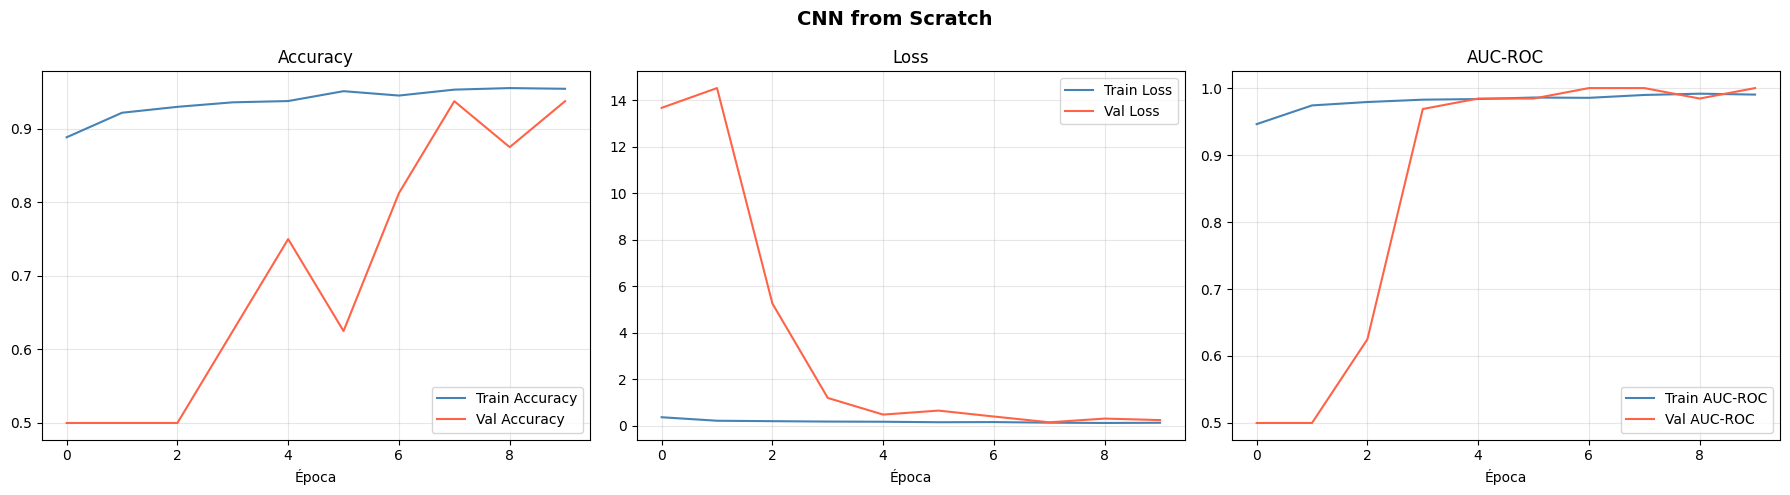

In [ ]:
# CURVAS DE ENTRENAMIENTO 
def plot_history(history, title="CNN from Scratch"):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    metrics = [('accuracy', 'Accuracy'), ('loss', 'Loss'), ('auc', 'AUC-ROC')]

    for ax, (metric, label) in zip(axes, metrics):
        ax.plot(history.history[metric],
                label=f'Train {label}', color='steelblue')
        ax.plot(history.history[f'val_{metric}'],
                label=f'Val {label}', color='tomato')
        ax.set_title(f'{label}', fontsize=12)
        ax.set_xlabel('Época')
        ax.legend()
        ax.grid(alpha=0.3)

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_history(history_scratch)

In [ ]:
# EVALUACIÓN EN TEST
# Cargar mejor modelo guardado
model_scratch = tf.keras.models.load_model('best_cnn_scratch.h5')

y_score_scratch = model_scratch.predict(X_test).flatten()
y_pred_scratch  = (y_score_scratch > 0.5).astype(int)

print("=" * 55)
print("  EVALUACIÓN — CNN FROM SCRATCH — TEST SET")
print("=" * 55)
print(classification_report(y_test, y_pred_scratch, target_names=CLASSES))
print(f"AUC-ROC: {roc_auc_score(y_test, y_score_scratch):.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step
  EVALUACIÓN — CNN FROM SCRATCH — TEST SET
              precision    recall  f1-score   support

      NORMAL       0.96      0.65      0.77       234
   PNEUMONIA       0.82      0.98      0.90       390

    accuracy                           0.86       624
   macro avg       0.89      0.81      0.83       624
weighted avg       0.87      0.86      0.85       624

AUC-ROC: 0.9497


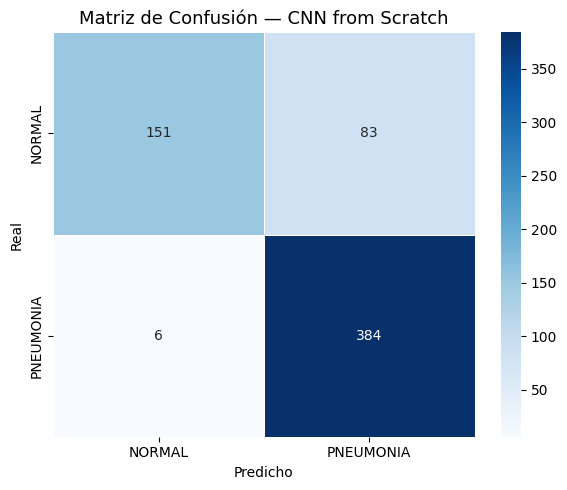


Verdaderos Negativos  (NORMAL correcto)    : 151
Falsos Positivos      (sano → enfermo)     : 83
Falsos Negativos      (enfermo → sano)   : 6
Verdaderos Positivos  (PNEUMONIA correcto) : 384


In [ ]:
#  de DLMATRIZ DE CONFUSIÓN
cm = confusion_matrix(y_test, y_pred_scratch)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', ax=ax,
            xticklabels=CLASSES, yticklabels=CLASSES,
            cmap='Blues', linewidths=0.5)
ax.set_title("Matriz de Confusión — CNN from Scratch", fontsize=13)
ax.set_xlabel("Predicho")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nVerdaderos Negativos  (NORMAL correcto)    : {tn}")
print(f"Falsos Positivos      (sano → enfermo)     : {fp}")
print(f"Falsos Negativos      (enfermo → sano)   : {fn}")
print(f"Verdaderos Positivos  (PNEUMONIA correcto) : {tp}")

## CNN v2 — Exploración de hiperparámetros

El modelo v1 tiene 4 bloques Conv2D + Flatten + Dense(256), lo que genera **13M de parámetros** en la capa densa. Para explorar si una arquitectura más compacta generaliza mejor, probamos una segunda configuración con los siguientes cambios:

1. **`GlobalAveragePooling2D`** en lugar de `Flatten` — reduce los parámetros del clasificador de ~13M a ~390K, forzando a la red a resumir cada mapa de características en un único valor antes de la clasificación.
2. **Dropout más agresivo (0.6)** — mayor regularización para reducir la dependencia de neuronas individuales.
3. **Learning rate más bajo (5e-5)** — entrenamiento más conservador.

Objetivo: comprobar si una red más pequeña y con más regularización mejora la generalización sobre el conjunto de test.


In [ ]:
# CNN v2: GlobalAveragePooling + Dropout agresivo 
def build_cnn_v2(input_shape=(224, 224, 1)):
    model = models.Sequential([
        # Bloque 1
        layers.Conv2D(32, (3, 3), activation='relu',
                      padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Bloque 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Bloque 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Bloque 4
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # GlobalAveragePooling en lugar de Flatten: reduce parámetros y overfitting
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.6),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

model_v2 = build_cnn_v2(INPUT_SHAPE)
model_v2.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 390,017 (1.49 MB)

 Trainable params: 389,057 (1.48 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
# COMPILAR Y CALLBACKS v2 
model_v2.compile(
    optimizer=optimizers.Adam(learning_rate=5e-5),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Recall(name='recall')]
)

cbs_v2 = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=3, min_lr=1e-7, verbose=1),
    callbacks.ModelCheckpoint('best_cnn_v2.h5', monitor='val_auc',
                              save_best_only=True, mode='max', verbose=1)
]


In [ ]:
# ENTRENAMIENTO v2 
history_v2 = model_v2.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=cbs_v2,
    verbose=1
)


Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.7739 - auc: 0.8259 - loss: 0.5403 - recall: 0.7872
Epoch 1: val_auc improved from None to 0.56250, saving model to best_cnn_v2.h5



Epoch 1: finished saving model to best_cnn_v2.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 34s 156ms/step - accuracy: 0.8062 - auc: 0.8821 - loss: 0.4492 - recall: 0.7977 - val_accuracy: 0.5000 - val_auc: 0.5625 - val_loss: 1.6035 - val_recall: 1.0000 - learning_rate: 5.0000e-05
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.8513 - auc: 0.9296 - loss: 0.3339 - recall: 0.8382
Epoch 2: val_auc improved from 0.56250 to 0.71094, saving model to best_cnn_v2.h5



Epoch 2: finished saving model to best_cnn_v2.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 24s 146ms/step - accuracy: 0.8652 - auc: 0.9370 - loss: 0.3154 - recall: 0.8511 - val_accuracy: 0.5000 - val_auc: 0.7109 - val_loss: 2.0714 - val_recall: 1.0000 - learning_rate: 5.0000e-05
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.8775 - auc: 0.9470 - loss: 0.2866 - recall: 0.8673
Epoch 3: val_auc improved from 0.71094 to 0.84375, saving model to best_cnn_v2.h5



Epoch 3: finished saving model to best_cnn_v2.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 25s 155ms/step - accuracy: 0.8861 - auc: 0.9507 - loss: 0.2768 - recall: 0.8756 - val_accuracy: 0.5000 - val_auc: 0.8438 - val_loss: 2.1794 - val_recall: 1.0000 - learning_rate: 5.0000e-05
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.8882 - auc: 0.9615 - loss: 0.2476 - recall: 0.8759
Epoch 4: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.

Epoch 4: val_auc did not improve from 0.84375
163/163 ━━━━━━━━━━━━━━━━━━━━ 25s 154ms/step - accuracy: 0.8928 - auc: 0.9601 - loss: 0.2498 - recall: 0.8818 - val_accuracy: 0.5000 - val_auc: 0.7969 - val_loss: 1.6452 - val_recall: 1.0000 - learning_rate: 5.0000e-05
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.9092 - auc: 0.9709 - loss: 0.2133 - recall: 0.8991
Epoch 5: val_auc improved from 0.84375 to 0.93750, saving model to best_cnn_v2.h5



Epoch 5: finished saving model to best_cnn_v2.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 24s 145ms/step - accuracy: 0.9091 - auc: 0.9708 - loss: 0.2149 - recall: 0.9001 - val_accuracy: 0.6250 - val_auc: 0.9375 - val_loss: 0.7011 - val_recall: 1.0000 - learning_rate: 2.5000e-05
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.9112 - auc: 0.9680 - loss: 0.2206 - recall: 0.9051
Epoch 6: val_auc did not improve from 0.93750
163/163 ━━━━━━━━━━━━━━━━━━━━ 25s 151ms/step - accuracy: 0.9082 - auc: 0.9687 - loss: 0.2203 - recall: 0.9004 - val_accuracy: 0.7500 - val_auc: 0.8281 - val_loss: 0.5588 - val_recall: 1.0000 - learning_rate: 2.5000e-05
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.9153 - auc: 0.9724 - loss: 0.2080 - recall: 0.9058
Epoch 7: val_auc improved from 0.93750 to 0.94531, saving model to best_cnn_v2.h5



Epoch 7: finished saving model to best_cnn_v2.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 25s 154ms/step - accuracy: 0.9158 - auc: 0.9735 - loss: 0.2058 - recall: 0.9066 - val_accuracy: 0.8125 - val_auc: 0.9453 - val_loss: 0.4179 - val_recall: 1.0000 - learning_rate: 2.5000e-05
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.9171 - auc: 0.9752 - loss: 0.1959 - recall: 0.9092
Epoch 8: val_auc improved from 0.94531 to 0.95312, saving model to best_cnn_v2.h5



Epoch 8: finished saving model to best_cnn_v2.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 24s 149ms/step - accuracy: 0.9156 - auc: 0.9733 - loss: 0.2039 - recall: 0.9099 - val_accuracy: 0.8125 - val_auc: 0.9531 - val_loss: 0.3075 - val_recall: 0.8750 - learning_rate: 2.5000e-05
Epoch 9/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.9134 - auc: 0.9725 - loss: 0.2088 - recall: 0.9063
Epoch 9: val_auc improved from 0.95312 to 0.98438, saving model to best_cnn_v2.h5



Epoch 9: finished saving model to best_cnn_v2.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 24s 147ms/step - accuracy: 0.9153 - auc: 0.9744 - loss: 0.2008 - recall: 0.9053 - val_accuracy: 0.8125 - val_auc: 0.9844 - val_loss: 0.4146 - val_recall: 1.0000 - learning_rate: 2.5000e-05
Epoch 10/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.9208 - auc: 0.9726 - loss: 0.2092 - recall: 0.9132
Epoch 10: val_auc did not improve from 0.98438
163/163 ━━━━━━━━━━━━━━━━━━━━ 25s 154ms/step - accuracy: 0.9222 - auc: 0.9768 - loss: 0.1913 - recall: 0.9146 - val_accuracy: 0.5625 - val_auc: 0.9609 - val_loss: 0.7094 - val_recall: 1.0000 - learning_rate: 2.5000e-05
Restoring model weights from the end of the best epoch: 8.


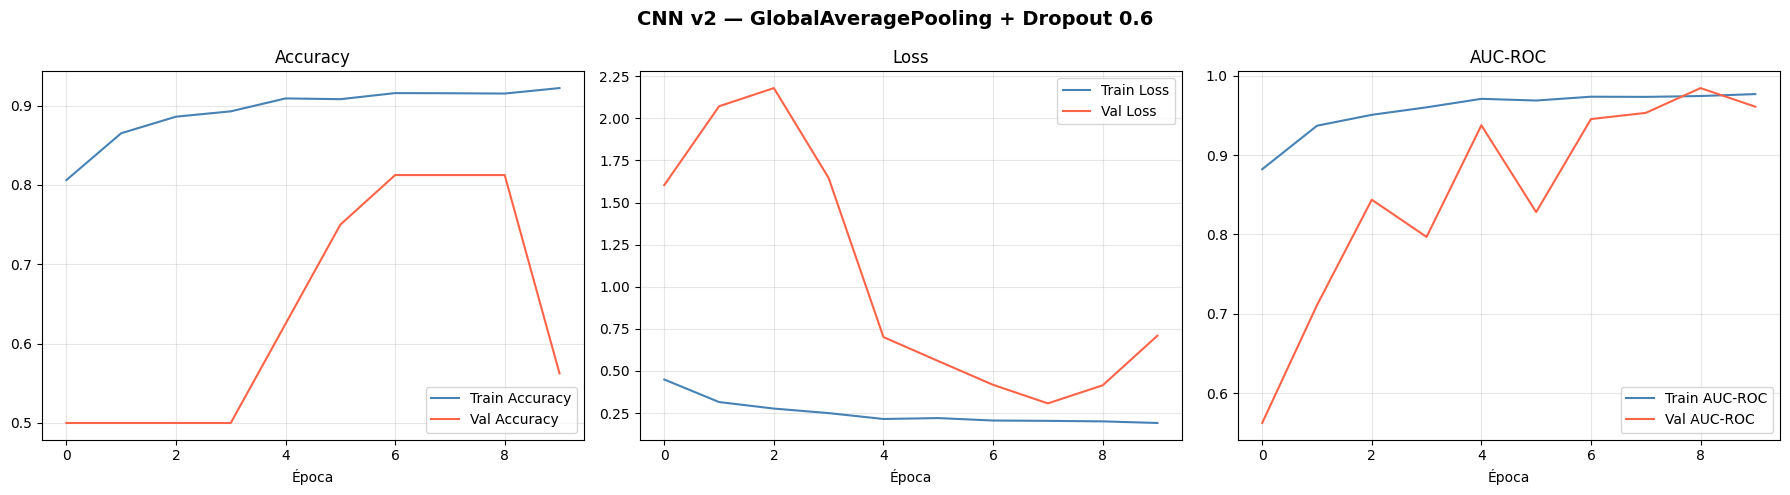

In [ ]:
# CURVAS DE ENTRENAMIENTO v2
plot_history(history_v2, title="CNN v2 — GlobalAveragePooling + Dropout 0.6")


In [ ]:
# EVALUACIÓN EN TEST v2 
model_v2 = tf.keras.models.load_model('best_cnn_v2.h5')

y_score_v2 = model_v2.predict(X_test).flatten()
y_pred_v2  = (y_score_v2 > 0.5).astype(int)

print("=" * 55)
print("  EVALUACIÓN — CNN v2 — TEST SET")
print("=" * 55)
print(classification_report(y_test, y_pred_v2, target_names=CLASSES))
print(f"AUC-ROC: {roc_auc_score(y_test, y_score_v2):.4f}")

# Sensibilidad y Especificidad explícitas
cm_v2 = confusion_matrix(y_test, y_pred_v2)
tn, fp, fn, tp = cm_v2.ravel()
sensibilidad  = tp / (tp + fn)   # recall de PNEUMONIA = detectar enfermos
especificidad = tn / (tn + fp)   # recall de NORMAL    = no generar falsas alarmas
print(f"\nSensibilidad  (Recall PNEUMONIA): {sensibilidad:.4f}")
print(f"Especificidad (Recall NORMAL)   : {especificidad:.4f}")


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
  EVALUACIÓN — CNN v2 — TEST SET
              precision    recall  f1-score   support

      NORMAL       0.85      0.80      0.82       234
   PNEUMONIA       0.89      0.91      0.90       390

    accuracy                           0.87       624
   macro avg       0.87      0.86      0.86       624
weighted avg       0.87      0.87      0.87       624

AUC-ROC: 0.9356

Sensibilidad  (Recall PNEUMONIA): 0.9128
Especificidad (Recall NORMAL)   : 0.8034


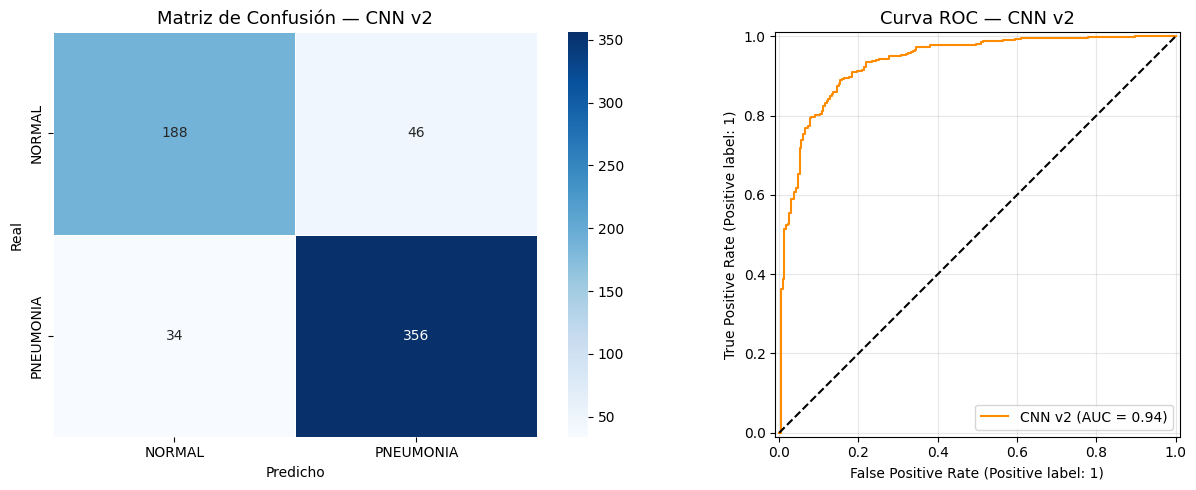

In [ ]:
# ─── MATRIZ DE CONFUSIÓN v2 + ROC ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
sns.heatmap(cm_v2, annot=True, fmt='d', ax=axes[0],
            xticklabels=CLASSES, yticklabels=CLASSES,
            cmap='Blues', linewidths=0.5)
axes[0].set_title("Matriz de Confusión — CNN v2", fontsize=13)
axes[0].set_xlabel("Predicho")
axes[0].set_ylabel("Real")

# ROC curve
RocCurveDisplay.from_predictions(
    y_test, y_score_v2,
    name="CNN v2",
    color="darkorange",
    ax=axes[1]
)
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title("Curva ROC — CNN v2", fontsize=13)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


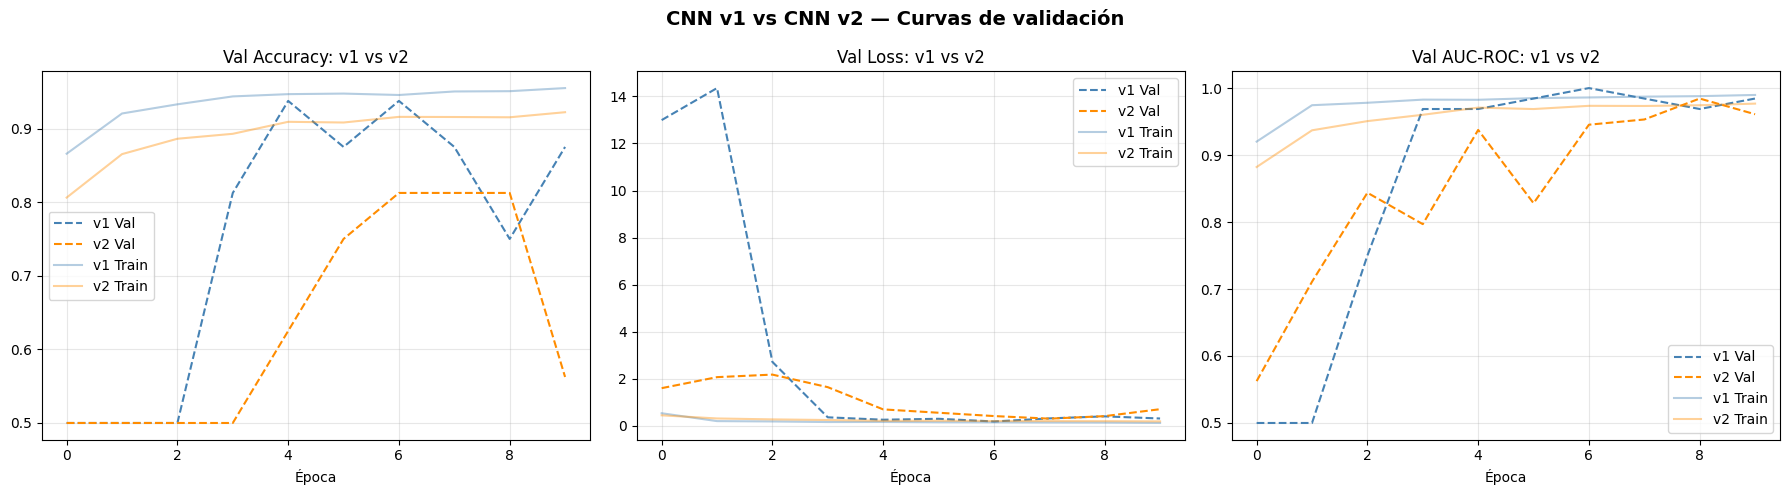


Modelo                     AUC-ROC  Sensibilidad  Especificidad
CNN v1 (Flatten+Dense)      0.9555        0.9359         0.8376
CNN v2 (GAP+Dropout0.6)     0.9356        0.9128         0.8034


In [ ]:
# COMPARACIÓN VISUAL v1 vs v2
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = [('accuracy', 'Accuracy'), ('loss', 'Loss'), ('auc', 'AUC-ROC')]

for ax, (metric, label) in zip(axes, metrics):
    ax.plot(history_scratch.history[f'val_{metric}'],
            label='v1 Val', color='steelblue', linestyle='--')
    ax.plot(history_v2.history[f'val_{metric}'],
            label='v2 Val', color='darkorange', linestyle='--')
    ax.plot(history_scratch.history[metric],
            label='v1 Train', color='steelblue', alpha=0.4)
    ax.plot(history_v2.history[metric],
            label='v2 Train', color='darkorange', alpha=0.4)
    ax.set_title(f'Val {label}: v1 vs v2', fontsize=12)
    ax.set_xlabel('Época')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("CNN v1 vs CNN v2 — Curvas de validación", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabla resumen
auc_v1  = roc_auc_score(y_test, y_score_scratch)
auc_v2  = roc_auc_score(y_test, y_score_v2)
cm_v1   = confusion_matrix(y_test, y_pred_scratch)
tn1, fp1, fn1, tp1 = cm_v1.ravel()
tn2, fp2, fn2, tp2 = cm_v2.ravel()

print("\n" + "=" * 65)
print(f"{'Modelo':<25} {'AUC-ROC':>8} {'Sensibilidad':>13} {'Especificidad':>14}")
print("=" * 65)
print(f"{'CNN v1 (Flatten+Dense)':<25} {auc_v1:>8.4f} "
      f"{tp1/(tp1+fn1):>13.4f} {tn1/(tn1+fp1):>14.4f}")
print(f"{'CNN v2 (GAP+Dropout0.6)':<25} {auc_v2:>8.4f} "
      f"{tp2/(tp2+fn2):>13.4f} {tn2/(tn2+fp2):>14.4f}")
print("=" * 65)


## Conclusiones — Deep Learning from Scratch


El primer modelo (CNN v1) obtuvo un AUC-ROC de 0.9497 con un recall de PNEUMONIA del 0.98 y tan solo 6 falsos negativos sobre 390 casos reales, superando al mejor modelo clásico (Logistic Regression, AUC-ROC = 0.927) y reduciendo los falsos positivos de 134 a 83. Sin necesidad de feature engineering manual, la CNN aprendió representaciones espaciales directamente de los píxeles, confirmando la ventaja del Deep Learning sobre HOG + PCA para este tipo de imágenes médicas.

La exploración de una segunda arquitectura (CNN v2, GAP + Dropout 0.6) buscaba mejorar la generalización mediante mayor regularización y menor número de parámetros. Sin embargo, no consiguió superar a la v1 en ninguna métrica relevante. La mayor regularización y el learning rate más bajo ralentizaron la convergencia sin aportar beneficio real en test, lo que sugiere que con ~5.000 imágenes el modelo v1, entrenado con data augmentation y class weights, ya aprovecha bien la capacidad disponible.

| Modelo | AUC-ROC | Recall PNEUMONIA | FN | FP |
|---|---|---|---|---|
| Logistic Regression (baseline) | 0.927 | 0.99 | 2 | 134 |
| CNN v1 (Flatten + Dense 256) | **0.9497** | **0.98** | **6** | **83** |
| CNN v2 (GAP + Dropout 0.6) | 0.9356 | 0.91 | 35 | 46 |

En términos clínicos, la CNN v1 es el mejor modelo from scratch: mejora el AUC-ROC respecto al baseline y reduce drásticamente los falsos positivos manteniendo una sensibilidad muy alta. No obstante, las curvas de validación presentan inestabilidad durante las primeras épocas, consecuencia directa del reducido tamaño del split de validación (16 imágenes) detectado en el EDA, lo que limita la fiabilidad de las métricas de validación epoch a epoch.

Esto motiva el salto a modelos preentrenados: arquitecturas que parten de representaciones aprendidas sobre millones de imágenes deberían permitir mejorar tanto la sensibilidad como la estabilidad del entrenamiento.